# No-Show Appointments Data Analysis Project

## Introduction
This project investigates a dataset containing information from 100k medical appointments in Brazil, focusing on whether or not patients show up for their scheduled appointments.

### Research Questions:
1. Does the patient's age affect their likelihood of showing up for an appointment?
2. Is there a relationship between gender and attendance rates?
3. Do certain neighbourhoods have higher no-show rates than others?
4. Does receiving an SMS reminder significantly improve appointment attendance?

In [1]:
# Import required data analysis and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data Wrangling & Cleaning Phase
In this section, the dataset is inspected, cleaned, and prepared to ensure reliability and accuracy before conducting any exploratory analysis:

1. **Inspecting Data Structure:** Loaded the dataset and examined its dimensions, data types, and missing values using `info()`, `describe()`, and `isnull().sum()`.
2. **Dropping Unnecessary Columns:** Removed irrelevant columns (`AppointmentID` and `PatientId`) that are not required for our analysis.
3. **Cleaning Column Names:** Standardized all column names to lowercase and removed extra whitespaces to ensure consistency and prevent errors during data calls.
4. **Removing Anomalies (Logical Errors):** Filtered out illogical records, specifically rows containing negative patient ages.
5. **Converting Data Types:** Transformed date columns (`scheduledday` and `appointmentday`) into proper datetime objects for temporal analysis.
6. **Encoding Target Variable:** Converted the text-based values ('Yes', 'No') in the `no-show` target column into numeric format (1, 0) using the `replace()` method to facilitate statistical operations and visualization.

In [3]:
# Load the dataset into a pandas DataFrame
df=pd.read_csv('/content/noshowappointments-kagglev2-may-2016.csv')

In [4]:
# Display the first few rows to inspect column names and structure
df.head(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [5]:
# Check dataset dimensions (rows and columns) and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [7]:
# Check for any missing (null) values in the dataset
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [8]:
# Generate summary statistics for numerical columns
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [9]:
# Convert all column names to lowercase for consistency
df.columns = df.columns.str.lower().str.strip()

In [10]:
# Remove invalid rows where age is negative
df = df[df['age'] >= 0]

In [11]:
# Verify the minimum age is now 0 or above
df['age'].min()

0

In [12]:
# Convert date columns to datetime format
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

In [18]:
# Convert patient ID to object (since IDs shouldn't be floats)
df['patientid'] = df['patientid'].astype(object)

In [16]:
# Replace No-show values with numeric format using replace function
df['no-show']= df['no-show'].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_871/2733439692.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['no-show']= df['no-show'].replace({'Yes': 1, 'No': 0})


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   patientid       110526 non-null  object             
 1   appointmentid   110526 non-null  int64              
 2   gender          110526 non-null  object             
 3   scheduledday    110526 non-null  datetime64[ns, UTC]
 4   appointmentday  110526 non-null  datetime64[ns, UTC]
 5   age             110526 non-null  int64              
 6   neighbourhood   110526 non-null  object             
 7   scholarship     110526 non-null  int64              
 8   hipertension    110526 non-null  int64              
 9   diabetes        110526 non-null  int64              
 10  alcoholism      110526 non-null  int64              
 11  handcap         110526 non-null  int64              
 12  sms_received    110526 non-null  int64              
 13  no-show         110

In [24]:
# Drop unnecessary columns that are not needed for analysis
df.drop(columns=['appointmentid', 'patientid'], inplace=True)


In [25]:
# Display the first few rows to verify the changes
df.head(3)

,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no-show
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0


In [26]:
# ==========================================
# Reusable Plot Customization Function
# Purpose: Standardizes titles, labels, grids,
# and layouts across all project visualizations.
# ==========================================
def customize_plot(title, xlabel, ylabel):
    """
    Function to customize plots with standard titles, labels, and grid lines.
    """
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

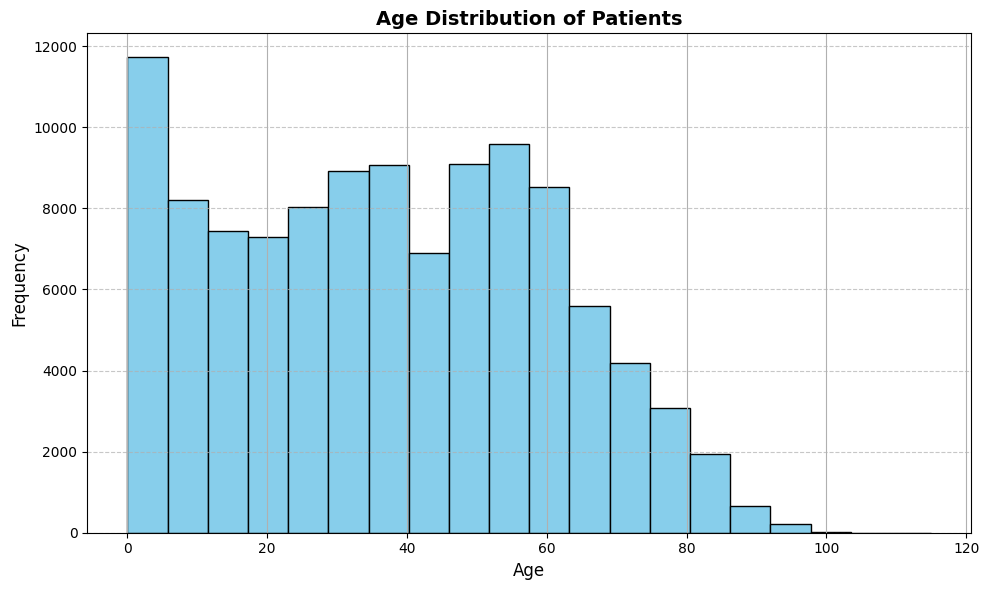

In [28]:
plt.figure(figsize=(10, 6))
df['age'].hist(bins=20, color='skyblue', edgecolor='black')
customize_plot('Age Distribution of Patients', 'Age', 'Frequency')
plt.show()

* **Why:** To understand the demographic distribution of patients and identify which age groups are most frequently booking appointments.
* **What:** The histogram shows that younger age groups and middle-aged patients make up a high volume of appointments, with a gradual decline among older adults.

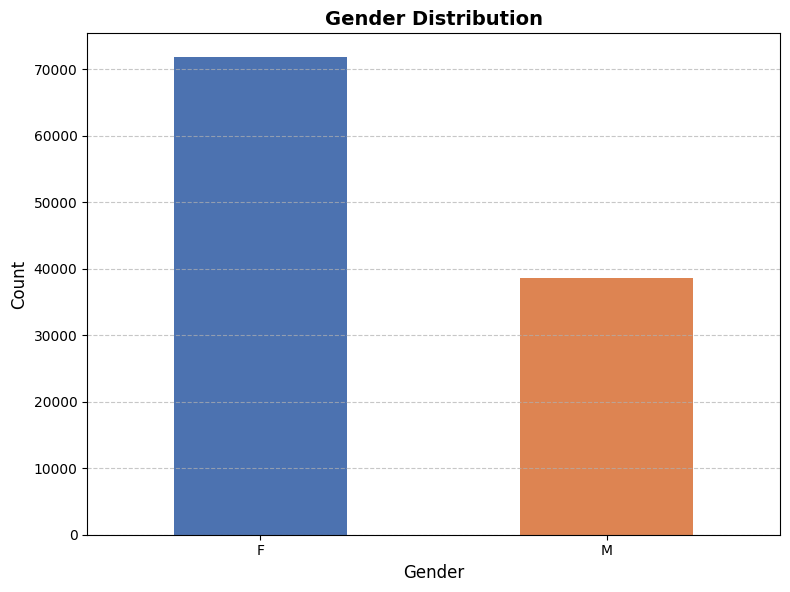

In [31]:
plt.figure(figsize=(8, 6))
df['gender'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
customize_plot('Gender Distribution', 'Gender', 'Count')
plt.xticks(rotation=0)
plt.show()

* **Why:** To investigate whether patient gender has any noticeable relationship or disparity in appointment booking volumes.
* **What:** The bar chart indicates that female patients account for a larger proportion of total appointments compared to male patients.

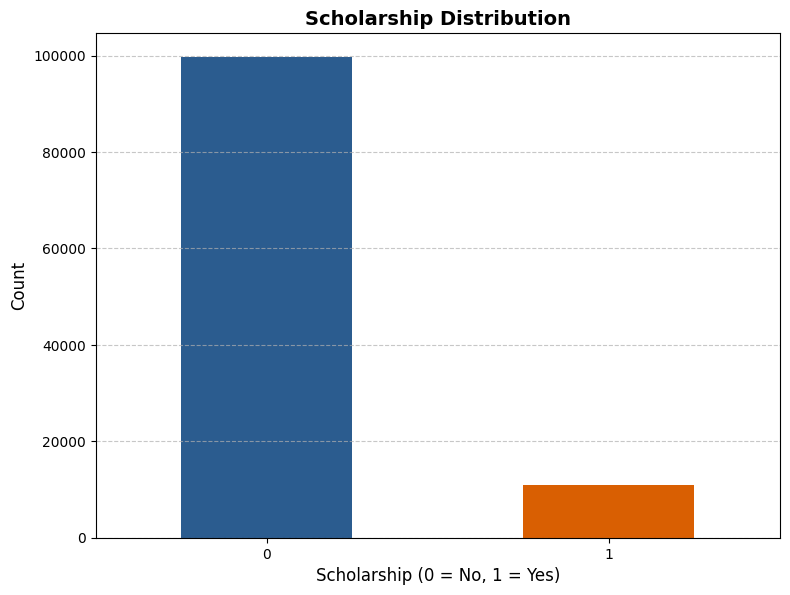

In [33]:
plt.figure(figsize=(8, 6))
df['scholarship'].value_counts().plot(kind='bar', color=['#2b5c8f', '#d95f02'])
customize_plot('Scholarship Distribution', 'Scholarship (0 = No, 1 = Yes)', 'Count')
plt.xticks(rotation=0)
plt.show()

* **Why:** To examine the proportion of patients enrolled in the Brazilian welfare program (Bolsa Família) and see how it forms part of our demographic variables.
* **What:** The bar chart shows that the vast majority of patients in the dataset are not enrolled in the scholarship program, while a smaller portion are beneficiaries.

In [36]:
# Grouping by Gender and calculating the mean of No-show to see the no-show rate per gender
gender_noshow = df.groupby('gender')['no-show'].mean()
gender_noshow

,no-show
gender,
F,0.203149
M,0.199679


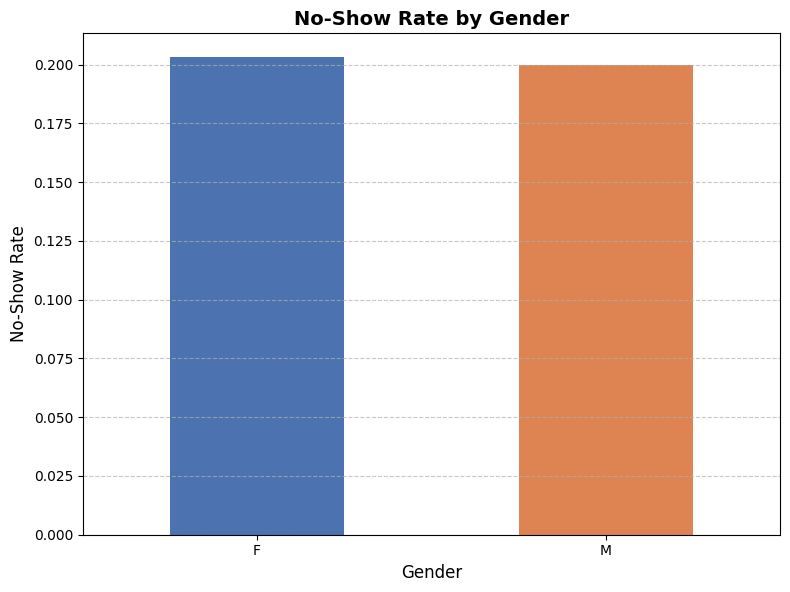

In [37]:
plt.figure(figsize=(8, 6))
gender_noshow.plot(kind='bar', color=['#4C72B0', '#DD8452'])
customize_plot('No-Show Rate by Gender', 'Gender', 'No-Show Rate')
plt.xticks(rotation=0)
plt.show()

* **Why:** To investigate whether the rate of missed appointments differs significantly between male and female patients.
* **What:** The bar chart shows that the no-show rate is nearly identical for both genders (around 20%), indicating that gender alone is not a strong predictor of appointment attendance.

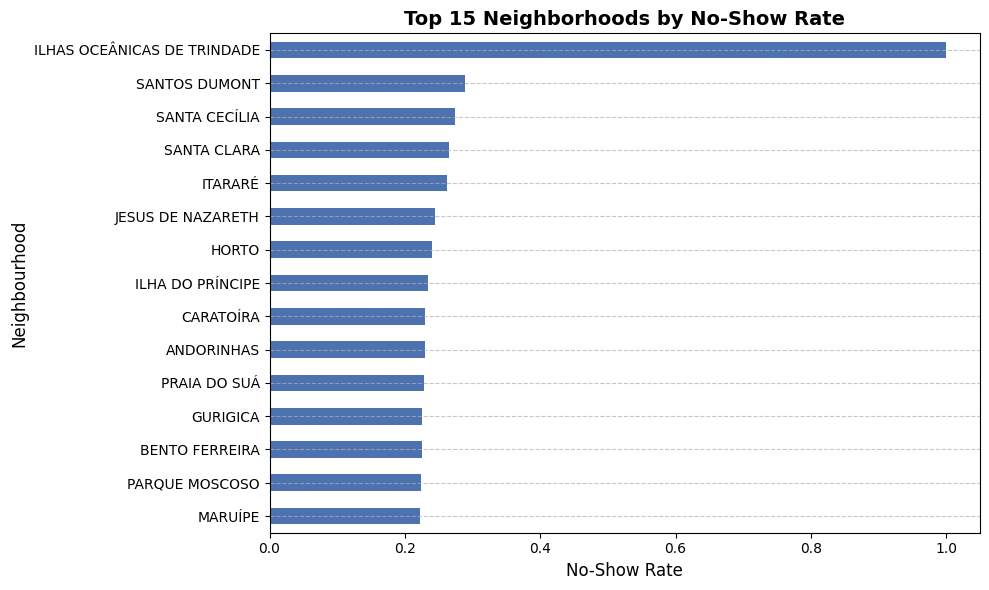

In [44]:
# Taking the top 15 neighbourhoods with the highest no-show rate for a clean, readable chart
neighbourhood_noshow = df.groupby('neighbourhood')['no-show'].mean().sort_values(ascending=True).tail(15)

# Plotting a clean horizontal bar chart
plt.figure(figsize=(10, 6))
neighbourhood_noshow.plot(kind='barh', color='#4C72B0')
customize_plot('Top 15 Neighborhoods by No-Show Rate', 'No-Show Rate', 'Neighbourhood')
plt.show()

* **Why:** To investigate if specific neighborhoods experience higher rates of missed appointments, which could help identify geographical patterns or access barriers.
* **What:** The horizontal bar chart shows the top 15 neighborhoods with the highest no-show rates, with "Ilhas Oceânicas de Trindade" showing the highest proportion compared to others.

sms_received
0    0.167035
1    0.275745
Name: no-show, dtype: float64


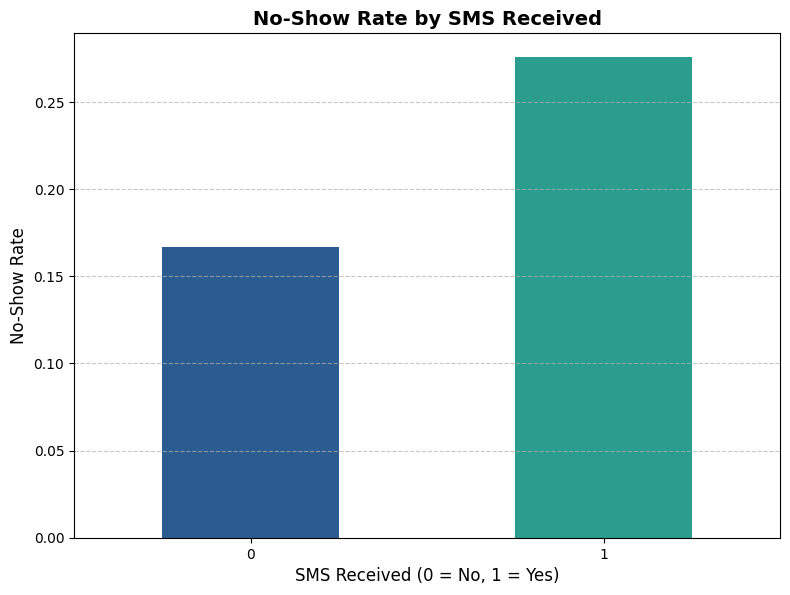

In [45]:
# Grouping by SMS_received and calculating the no-show rate
sms_noshow = df.groupby('sms_received')['no-show'].mean()

print(sms_noshow)

# Plotting the results
plt.figure(figsize=(8, 6))
sms_noshow.plot(kind='bar', color=['#2b5c8f', '#2a9d8f'])
customize_plot('No-Show Rate by SMS Received', 'SMS Received (0 = No, 1 = Yes)', 'No-Show Rate')
plt.xticks(rotation=0)
plt.show()

* **Why:** To determine whether receiving an SMS reminder has a positive impact on patient attendance and reduces the no-show rate.
* **What:** The analysis unexpectedly shows a higher no-show rate for patients who received SMS reminders compared to those who didn't. This suggests that SMS reminders are likely targeted or triggered disproportionately for high-risk patients—such as those with a history of missing appointments or strict institutional follow-up policies (e.g., warnings due to repeated absences).

Conclusions

Based on the exploratory data analysis (EDA) of the No-Show Appointments dataset, the conclusions are limited strictly to the features analyzed in the notebook:

Gender Analysis: Gender showed no significant difference in appointment attendance, with female and male patients exhibiting nearly identical no-show rates (approximately 20%).

Geographical Factors: Certain neighbourhoods recorded noticeably higher rates of missed appointments, suggesting that geographical location or access barriers may influence attendance patterns.

SMS Reminders: Patients who received SMS reminders showed higher no-show rates, indicating that reminders are likely targeted primarily toward high-risk patients.

Scholarship Distribution: The vast majority of patients in the dataset are not enrolled in the scholarship program, while a smaller portion are beneficiaries.

Limitations

Correlation vs. Causation: The findings identify statistical patterns (e.g., between neighbourhood/SMS status and no-shows) rather than proven causal relationships.

Lack of Contextual Data: The dataset lacks qualitative and detailed external variables, such as weather conditions, traffic status, or specific reasons why patients missed appointments.

Administrative Bias in SMS Data: The data does not explain the clinic's internal policy or criteria for sending SMS notifications, which limits our ability to evaluate the true effectiveness of the reminder system.